In [53]:
from typing import TypedDict,Optional,Dict,List
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel,Field
import os 
import re
from PyPDF2 import PdfReader

In [54]:
### Define the state 

class MedicalValidationState(TypedDict,total=False):
    member_id:Optional[int]
    valid: Optional[bool]
    docs:Optional[List[str]]
    docs_validate:Optional[bool]
    extracted: Optional[Dict[str,str]]

    age: Optional[int]
    policy_text: Optional[str]
    policy_validation_result: Optional[Dict]


class PolicyValidationOutput(BaseModel):
    is_covered:bool =Field(
        description ="true if this claim is covered under the policy at all "
    )

    covered_status: str= Field(
        description = "One of : 'Fully covered', 'not covered', 'partially covered' "
    )

    reason: str =Field(
        description="One paragprah natural language explaination of the covered decision"
    )

    allowed_amount_estimate: Optional[float]=Field (
        default=None,
        description="Estimated amount payable as per policy"
    )

    disallowed_reason : List[str]=Field(
        default_factory=list,
        description="List of reason for any partial/non-coverage"
    )

    flags: List[str] = Field (
        default_factory=list,
        description="Any flags like 'pre-existing', 'waiting perion', 'Need manual review' "
    )



## Nodes 

In [55]:
#### node 1 
def ask_member_id(state:MedicalValidationState)->Dict:
    """
    1. Ask for member id .
     Graph handles looping through conditional edges
    """
    member_id=input("Please enter the member id:").strip()
    return{"member_id":member_id} 


In [56]:
### node 2 
def validate_member_id(state:MedicalValidationState)->Dict:
    """
    step2 : Validate the member id, set 'valid' flag. 
    """
    member_id=(state.get("member_id") or "").strip() 
    valid= len(member_id) >=5

    if not valid:
        print("Invalid member id, it should be atlest 5 characters")
    else: 
        print("member id validated")

    return {"valid":valid}         

In [57]:
## node 3 
def request_docs(state: MedicalValidationState) -> Dict:
    allowed_ext = {".pdf"}

    def is_valid_pdf(name: str) -> bool:
        if not name:
            return False
        cleaned = name.strip().strip('"').strip("'")
        ext = os.path.splitext(cleaned)[1].lower()
        print(f"[is_valid_pdf] name={name!r}, cleaned={cleaned!r}, ext={ext!r}")
        return ext in allowed_ext

    claim_doc = input("Enter CLAIM PDF path/name: ").strip()
    discharge_doc = input("Enter DISCHARGE SUMMARY PDF path/name: ").strip()

    docs = [claim_doc, discharge_doc]
    ok = is_valid_pdf(claim_doc) and is_valid_pdf(discharge_doc)

    print(f"[request_docs] docs={docs}, docs_valid={ok}")

    if not ok:
        print("❌ Both files must be PDF (.pdf). Please try again.\n")

    return {
        "docs": docs,
        "docs_valid": ok,
    }


In [58]:

## node 4 
def _read_pdf_text(path: str) -> str:
    """Read all text from a PDF file using PyPDF2."""
    try:
        reader = PdfReader(path)
        texts = []
        for page in reader.pages:
            page_text = page.extract_text() or ""
            texts.append(page_text)
        return "\n".join(texts)
    except Exception as e:
        print(f"⚠ Error reading PDF {path!r}: {e}")
        return ""


def _extract_field(patterns, text: str, default: str = "Unknown") -> str:
    """
    Try multiple regex patterns, return first match (group 1 or last group).
    """
    for pat in patterns:
        m = re.search(pat, text, flags=re.IGNORECASE)
        if m:
            # use last group if there are many
            return m.group(m.lastindex or 1).strip()
    return default


def extract_claim(state: MedicalValidationState) -> Dict:
    """ 
    Step 4 : Automatic Claim Extraction from two PDFs.
    Expects state["docs"] = [claim_pdf_path, discharge_pdf_path]
    """
    docs = state.get("docs", [])
    print(f"[extract_claim] Extracting from docs: {docs}")

    if len(docs) != 2:
        print("⚠ Expected exactly two PDFs (claim + discharge).")
        return {"extracted": {
            "name": "Unknown",
            "disease": "Unknown",
            "total_amount": "Unknown",
        }}

    claim_pdf, discharge_pdf = docs

    # 1) Read both PDFs
    claim_text = _read_pdf_text(claim_pdf)
    discharge_text = _read_pdf_text(discharge_pdf)

    # Combine texts for more robust extraction
    full_text = claim_text + "\n" + discharge_text

    # 2) Extract Name
    name_patterns = [
        r"Patient Name[:\-]\s*(.+)",
        r"Name[:\-]\s*(.+)",
        r"Member Name[:\-]\s*(.+)",
    ]
    name = _extract_field(name_patterns, full_text, default="Unknown")

    # 3) Extract Disease / Diagnosis
    disease_patterns = [
        r"(?:Disease|Diagnosis|Primary Diagnosis)[:\-]\s*(.+)",
        r"Diagnosed with[:\-]\s*(.+)",
    ]
    disease = _extract_field(disease_patterns, full_text, default="Unknown")

    # 4) Extract Total Amount
    amount_patterns = [
        r"(?:Total\s+(?:Claim(?:ed)?|Bill|Amount)|Total Claimed Amount)[:\-]?\s*([₹$]?\s?[\d,]+)",
        r"Total Bill Amount[:\-]?\s*([₹$]?\s?[\d,]+)",
    ]
    total_amount = _extract_field(amount_patterns, full_text, default="Unknown")

    extracted = {
        "name": name,
        "disease": disease,
        "total_amount": total_amount,
    }

    print(f"[extract_claim] Extracted: {extracted}\n")

    return {"extracted": extracted}


In [59]:
from dotenv import load_dotenv
load_dotenv()
import os 
import json

os.environ['GROQ_API_KEY']= os.getenv('GROQ_API_KEY')
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")


In [60]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document  # already used elsewhere

# -------- VECTOR DB CONFIG ---------

VECTOR_DB_DIR = "/Users/ashis/Documents/langraph_medical_validation/vectorstores/policies"
COLLECTION_NAME = "health_policy_docs"
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Load embedding model (same one used during preprocessing)
_embeddings = HuggingFaceEmbeddings(model_name=EMBED_MODEL_NAME)

# Load Chroma vector store
_vectordb = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=_embeddings,
    persist_directory=VECTOR_DB_DIR,
)

# Create retriever to fetch relevant policy clauses
policy_retriever = _vectordb.as_retriever(search_kwargs={"k": 6})




Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [61]:
def policy_validation_agent(state: MedicalValidationState) -> Dict:
    """
    RAG-based policy validation agent.

    Uses:
      - extracted fields from claim (disease, total_amount)
      - patient's age (asked once if missing)
      - policy clauses retrieved from Chroma vector DB

    LLM returns JSON with:
      - coverage_status
      - is_covered
      - reason
      - allowed_amount_estimate
      - disallowed_reasons
      - flags

    Stored under: state["policy_validation_result"]
    """

    # -------- Extract claim details from state --------
    extracted = state.get("extracted") or {}
    disease = (extracted.get("disease") or "Unknown").strip()
    claim_amount_text = (extracted.get("total_amount") or "Unknown").strip()

    age = state.get("age")
    if age is None:
        age_str = input("Enter patient's age: ").strip()
        try:
            age = int(age_str)
        except ValueError:
            age = None

    print(f"[policy_validation_agent] age={age}, disease={disease}, claim_amount={claim_amount_text}")

    # -------- Retrieve relevant policy clauses from Chroma --------
    base_query = (
        f"Disease: {disease}. "
        f"Patient age: {age}. "
        f"Claim amount: {claim_amount_text}. "
        "Find health insurance policy clauses about coverage, waiting periods, exclusions, "
        "pre-existing disease rules, co-pay, sub-limits, and disease-specific limits."
    )

    print("[policy_validation_agent] Retrieving policy context from vector DB...")
    try:
        docs = policy_retriever.invoke(base_query)
    except Exception as e:
        print(f"⚠ Retrieval error: {e}")
        docs = []

    print(f"[policy_validation_agent] Retrieved {len(docs)} docs from RAG")

    if not docs:
        context_text = (
            "No policy context could be retrieved from the vector store. "
            "You must answer conservatively and flag for manual review."
        )
    else:
        context_chunks = []
        for i, d in enumerate(docs, start=1):
            context_chunks.append(
                f"[Clause {i} | policy_id={d.metadata.get('policy_id')}] \n{d.page_content}"
            )
        context_text = "\n\n".join(context_chunks)

        # Optional: show a preview to debug what RAG is returning
        print("\n[policy_validation_agent] Sample retrieved clause:")
        print(context_chunks[0][:600], "...\n")

    # -------- LLM instructions --------
    instructions = """
Return ONLY a valid JSON object with the following keys:

- "coverage_status": one of "Fully covered", "Partially covered", "Not covered"
- "is_covered": true or false
- "reason": string explanation for the decision, referencing policy clauses when relevant
- "allowed_amount_estimate": number or null (best estimate of payable amount). If you cannot estimate, use null.
- "disallowed_reasons": array of strings (reasons for partial or non-coverage; empty array if none)
- "flags": array of strings (e.g., "Waiting period to be checked", "Needs manual TPA review"; empty array if none)

Do NOT include any backticks, markdown code fences, or text outside the JSON.
"""

    user_prompt = f"""
You are an expert health insurance underwriter.

Below are the relevant sections from one or more health insurance policy documents:
\"\"\" 
{context_text}
\"\"\"

Claim details:
- Patient Age: {age}
- Diagnosis / Disease: {disease}
- Claimed Amount (as text): {claim_amount_text}

Using ONLY the policy clauses above (do not invent new rules), decide whether this claim is covered.
Consider:
- Coverage vs. exclusions
- Waiting periods (initial, disease-specific, pre-existing)
- Co-pay
- Sub-limits
- Age-based restrictions
- Any disease-specific caps or examples

Then respond as per the JSON schema described below.

{instructions}
"""

    print("[policy_validation_agent] Calling Groq LLM...")
    resp = llm.invoke(user_prompt)
    raw_text = resp.content if hasattr(resp, "content") else str(resp)

    print("\n[policy_validation_agent] Raw LLM response:")
    print(raw_text)

    # -------- JSON parsing (robust) --------
    data = None

    # 1) Try direct JSON
    try:
        data = json.loads(raw_text)
    except json.JSONDecodeError:
        # 2) Try to extract last {...} block from the text
        matches = re.findall(r"\{.*\}", raw_text, re.DOTALL)
        if matches:
            try:
                data = json.loads(matches[-1])
            except json.JSONDecodeError:
                data = None

    if data is None:
        print("⚠ Could not parse JSON from LLM response, storing raw text.")
        return {
            "age": age,
            "policy_validation_result": {"raw": raw_text}
        }

    # -------- Normalize keys & fill defaults --------
    result = {
        "coverage_status": data.get("coverage_status"),
        "is_covered": data.get("is_covered"),
        "reason": data.get("reason"),
        "allowed_amount_estimate": data.get("allowed_amount_estimate"),
        "disallowed_reasons": data.get("disallowed_reasons", []) or [],
        "flags": data.get("flags", []) or [],
    }

    print("\n[policy_validation_agent] Parsed decision:")
    print(result)
    print("----------------------------------\n")

    # Keep age in state for future nodes as well
    return {
        "age": age,
        "policy_validation_result": result,
    }


GRAPH WIRING

In [62]:
graph=StateGraph(MedicalValidationState)

graph.add_node("ask_member_id",ask_member_id)
graph.add_node("validate_member_id",validate_member_id)
graph.add_node("request_docs",request_docs)
graph.add_node("extract_claim",extract_claim)
graph.add_node("policy_validation_agent", policy_validation_agent) 


graph.add_edge(START,"ask_member_id")
graph.add_edge("ask_member_id","validate_member_id")


#### loop 1: reasking member id until valid =True
graph.add_conditional_edges(
    "validate_member_id",
    lambda s: bool(s.get("valid",False)),
    {
        True :"request_docs",
        False:"ask_member_id" 
    }
)

#### loop 2 : re-asking docs until doc_valid =True 

graph.add_conditional_edges(
    "request_docs",
    lambda s : bool(s.get("docs_valid",False)),
    {
        True: "extract_claim",
        False : "request_docs"
    },
)


graph.add_edge("extract_claim", "policy_validation_agent")
graph.add_edge("policy_validation_agent", END)


claim_flow=graph.compile()

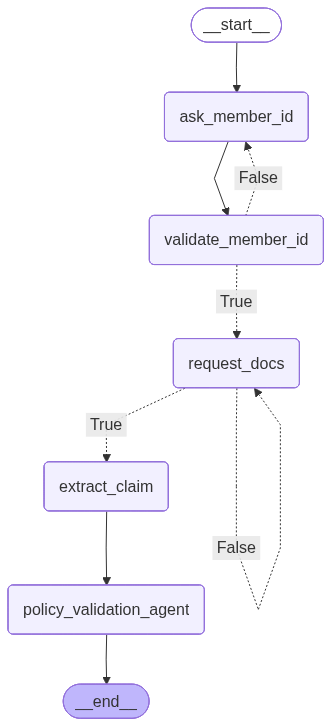

In [63]:
from IPython.display import Image, display

# If you already have `claim_flow` compiled:
graph_viz = claim_flow.get_graph()

# Mermaid PNG
display(Image(graph_viz.draw_mermaid_png()))

In [64]:
final_state = claim_flow.invoke({}, config={"recursion_limit": 100})
decision = final_state.get("policy_validation_result", {})

print("\n---- Policy Validation Result ----")
print(f"Coverage Status : {decision.get('coverage_status')}")
print(f"Is Covered      : {decision.get('is_covered')}")
print(f"Reason          : {decision.get('reason')}")
print(f"Allowed Amount  : {decision.get('allowed_amount_estimate')}")
print(f"Disallowed      : {', '.join(decision.get('disallowed_reasons', [])) or 'None'}")
print(f"Flags           : {', '.join(decision.get('flags', [])) or 'None'}")
print("----------------------------------")


member id validated
[is_valid_pdf] name='/Users/ashis/Downloads/sample_discharge_summary.pdf', cleaned='/Users/ashis/Downloads/sample_discharge_summary.pdf', ext='.pdf'
[is_valid_pdf] name='/Users/ashis/Downloads/sample_claim.pdf', cleaned='/Users/ashis/Downloads/sample_claim.pdf', ext='.pdf'
[request_docs] docs=['/Users/ashis/Downloads/sample_discharge_summary.pdf', '/Users/ashis/Downloads/sample_claim.pdf'], docs_valid=True
[extract_claim] Extracting from docs: ['/Users/ashis/Downloads/sample_discharge_summary.pdf', '/Users/ashis/Downloads/sample_claim.pdf']
[extract_claim] Extracted: {'name': 'John Doe', 'disease': 'Acute Plasmodium Falciparum Malaria', 'total_amount': '$4,500'}

[policy_validation_agent] age=43, disease=Acute Plasmodium Falciparum Malaria, claim_amount=$4,500
[policy_validation_agent] Retrieving policy context from vector DB...
[policy_validation_agent] Retrieved 6 docs from RAG

[policy_validation_agent] Sample retrieved clause:
[Clause 1 | policy_id=Policy_Advanc